In [1]:
# 1. 라이브러리 불러오기 및 실습 데이터 생성
# 실습을 위해 변수 간의 단위 차이가 크고, 이상치(Outlier)가 포함된 가상의 고객 데이터를 생성.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 실습용 데이터 세트 생성
data = {
    '나이': [25, 30, 45, 22, 35, 28, 65, 31, 29, 38],          # 20 ~ 65 사이의 분포
    '연봉(만원)': [3500, 4200, 6000, 2800, 5000, 3800, 25000, 41000, 3900, 4800] # 이상치(25000, 41000) 포함
}

df = pd.DataFrame(data)
print("--- 원본 데이터 ---")
print(df)

--- 원본 데이터 ---
   나이  연봉(만원)
0  25    3500
1  30    4200
2  45    6000
3  22    2800
4  35    5000
5  28    3800
6  65   25000
7  31   41000
8  29    3900
9  38    4800


In [2]:
# 2. MinMaxScaler (정규화)
# 원리: 데이터를 모두 0과 1 사이의 범위로 압축합니다.
# 특징: 데이터의 최소값은 0, 최대값은 1이 됩니다. 데이터의 분포 형상은 그대로 유지되나, 이상치가 있을 경우 정상 데이터들이 좁은 영역으로 촘촘하게 뭉치는 경향이 있다.

from sklearn.preprocessing import MinMaxScaler

# 1. 스케일러 객체 생성
minmax_scaler = MinMaxScaler()

# 2. 데이터 학습 및 변환 (fit_transform)
# fit: 데이터의 최소/최대값을 탐색, transform: 공식에 맞춰 변환
df_minmax = df.copy()
df_minmax[['나이', '연봉(만원)']] = minmax_scaler.fit_transform(df[['나이', '연봉(만원)']])

print("--- 1. MinMaxScaler 적용 결과 (0 ~ 1 사이) ---")
print(df_minmax)

--- 1. MinMaxScaler 적용 결과 (0 ~ 1 사이) ---
         나이    연봉(만원)
0  0.069767  0.018325
1  0.186047  0.036649
2  0.534884  0.083770
3  0.000000  0.000000
4  0.302326  0.057592
5  0.139535  0.026178
6  1.000000  0.581152
7  0.209302  1.000000
8  0.162791  0.028796
9  0.372093  0.052356


In [3]:
# 3. StandardScaler (표준화)
# 원리: 데이터를 평균이 0, 표준편차가 1인 정규분포 모양으로 변환.
# 특징: 데이터의 상한과 하한이 정해져 있지 않습니다. 이상치(Outlier)가 존재하는 데이터셋에서 MinMaxScaler보다 이상치의 영향을 덜 받기 때문에 상대적으로 안전.

from sklearn.preprocessing import StandardScaler

# 1. 스케일러 객체 생성
std_scaler = StandardScaler()

# 2. 데이터 학습 및 변환
df_std = df.copy()
df_std[['나이', '연봉(만원)']] = std_scaler.fit_transform(df[['나이', '연봉(만원)']])

print("--- 2. StandardScaler 적용 결과 (평균 0, 표준편차 1) ---")
print(df_std)

--- 2. StandardScaler 적용 결과 (평균 0, 표준편차 1) ---
         나이    연봉(만원)
0 -0.827188 -0.538420
1 -0.405153 -0.480436
2  0.860951 -0.331335
3 -1.080409 -0.596403
4  0.016881 -0.414169
5 -0.573967 -0.513570
6  2.549091  1.242507
7 -0.320746  2.567848
8 -0.489560 -0.505286
9  0.270102 -0.430736


C:\Users\kz4ne\AppData\Local\Temp\ipykernel_30008\4216828665.py:21: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\DEV\dp_312\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


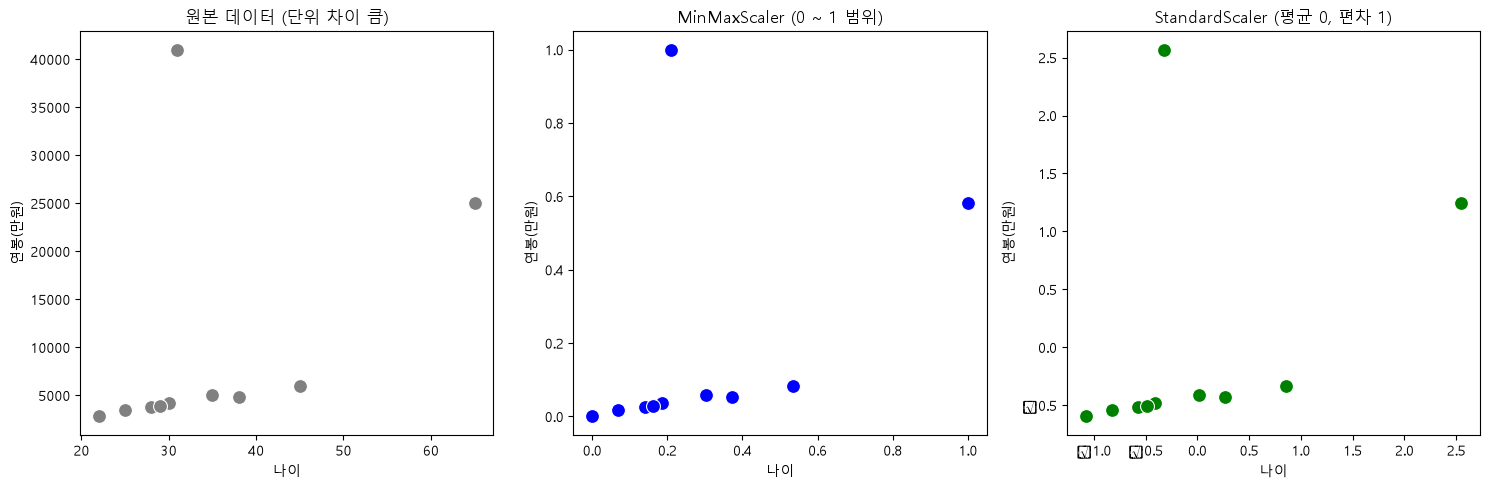

In [4]:
# 4. 시각화를 통한 변환 효과 비교
# 스케일링 전과 후, 데이터의 스케일(축 범위)이 어떻게 바뀌었는지 그래프로 직관적으로 확인.

# 한글 깨짐 방지 설정
plt.rc('font', family='Malgun Gothic')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# [1] 원본 데이터 분포
sns.scatterplot(x='나이', y='연봉(만원)', data=df, ax=axes[0], color='gray', s=100)
axes[0].set_title('원본 데이터 (단위 차이 큼)')

# [2] MinMaxScaler 변환 분포
sns.scatterplot(x='나이', y='연봉(만원)', data=df_minmax, ax=axes[1], color='blue', s=100)
axes[1].set_title('MinMaxScaler (0 ~ 1 범위)')

# [3] StandardScaler 변환 분포
sns.scatterplot(x='나이', y='연봉(만원)', data=df_std, ax=axes[2], color='green', s=100)
axes[2].set_title('StandardScaler (평균 0, 편차 1)')

plt.tight_layout()
plt.show()